# CIFAR-10 — Modelowanie

**Autorzy:** Piotr Dyga, Wiktor Bojarski, Mateusz Madej

Notebook prowadzi przez sześć etapów: od surowego baseline'u, przez wybór optymalizatora
i strojenie hiperparametrów (grid search), aż po głębsze architektury (VGG-like, ResNet-like).
Cała logika znajduje się w module `src/cifar10_pipeline.py` — tutaj tylko wywołujemy
jego funkcje i interpretujemy wyniki.

Każdy eksperyment zapisuje swoje artefakty w `experiments/` (config, metryki, historia,
wagi, wykresy) i dopisuje wiersz do `experiments/results_summary.csv`. Grid search jest
**wznawialny** — ukończone konfiguracje są pomijane przy ponownym uruchomieniu.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Korzen projektu: notebook lezy w notebooks/, modul w src/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
import cifar10_pipeline as cp

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"
CLASS_NAMES = cp.CIFAR10_CLASSES

# Wykrywanie lokalizacji danych (data/ lub korzen projektu).
_candidates = [PROJECT_ROOT / "data" / "cifar10_preprocessed.npz",
               PROJECT_ROOT / "cifar10_preprocessed.npz"]
DATA_PATH = next((p for p in _candidates if p.exists()), _candidates[0])
print("PROJECT_ROOT:", PROJECT_ROOT)
print("Dane:", DATA_PATH, "| istnieje:", DATA_PATH.exists())

PROJECT_ROOT: c:\Users\matma\Documents\SGH\SEM II\Deep learning\Projekt_CIFAR10
Dane: c:\Users\matma\Documents\SGH\SEM II\Deep learning\Projekt_CIFAR10\data\cifar10_preprocessed.npz | istnieje: True


## Sanity-check GPU

Krótki test, że PyTorch widzi kartę i potrafi na niej liczyć. To ważne na RTX 5070
(Blackwell, `sm_120`) — wymaga buildu PyTorcha pod CUDA 12.8, inaczej kernele nie działają.

In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA dostepne:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    # Faktyczne mnozenie na GPU — weryfikuje, ze kernele dzialaja na tej karcie.
    _x = torch.randn(2000, 2000, device="cuda")
    _ = (_x @ _x).sum().item()
    print("Test obliczen na GPU: OK")

device = cp.get_device()
print("Uzywane urzadzenie:", device)

PyTorch: 2.11.0+cu128
CUDA dostepne: True
GPU: NVIDIA GeForce RTX 5070 Laptop GPU
Test obliczen na GPU: OK
Uzywane urzadzenie: cuda


## Wczytanie danych i podział train / val / test

Dane są już przetworzone (float32 w `[0, 1]`). Zbiór treningowy dzielimy na train/val
(10% na walidację, ze stratyfikacją). **Zbiór testowy ruszamy dopiero dla finalnych modeli** —
selekcja i early stopping opierają się wyłącznie na walidacji.

In [3]:
x_train_full, y_train_full, x_test, y_test = cp.load_data(DATA_PATH)
x_train, y_train, x_val, y_val = cp.stratified_split(x_train_full, y_train_full, val_size=0.1)

# Wspolna krotka danych przekazywana do kazdego eksperymentu.
data = (x_train, y_train, x_val, y_val, x_test, y_test)

print("Train:", x_train.shape, "| Val:", x_val.shape, "| Test:", x_test.shape)
print("Zakres pikseli:", float(x_train.min()), "-", float(x_train.max()))
print("Rozklad klas w val:", np.bincount(y_val))

Train: (45000, 32, 32, 3) | Val: (5000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Zakres pikseli: 0.0 - 1.0
Rozklad klas w val: [500 500 500 500 500 500 500 500 500 500]


## Etap 1 — Baseline CNN

**Pytanie badawcze:** gdzie lądujemy bez żadnych optymalizacji?

Trenujemy prostą sieć (3 bloki Conv-BN-ReLU-MaxPool + głowa FC) w surowej konfiguracji:
optymalizator Adam (lr=0.001), batch=128, bez augmentacji, bez normalizacji, bez schedulera
i bez label smoothingu. To celowo „goły" punkt odniesienia — bez żadnych optymalizacji.

In [13]:
config_baseline = dict(
    arch="baseline", optimizer="adam", lr=0.001, batch_size=128,
    dropout=0.5, augment=False, normalize=False, scheduler="none",
    label_smoothing=0.0, weight_decay=0.0,
    max_epochs=100, patience=15, seed=42, num_workers=0,
)
res_baseline = cp.run_experiment(
    config_baseline, data, device, EXPERIMENTS_DIR,
    category="baseline", evaluate_test=True,
)
print("Parametry modelu:", f"{res_baseline['num_params']:,}")

[pomijam trening] baseline/baseline_bs128_lr0.001_drop0.5_aug0 juz istnieje — wczytuje wyniki.
Parametry modelu: 620,586


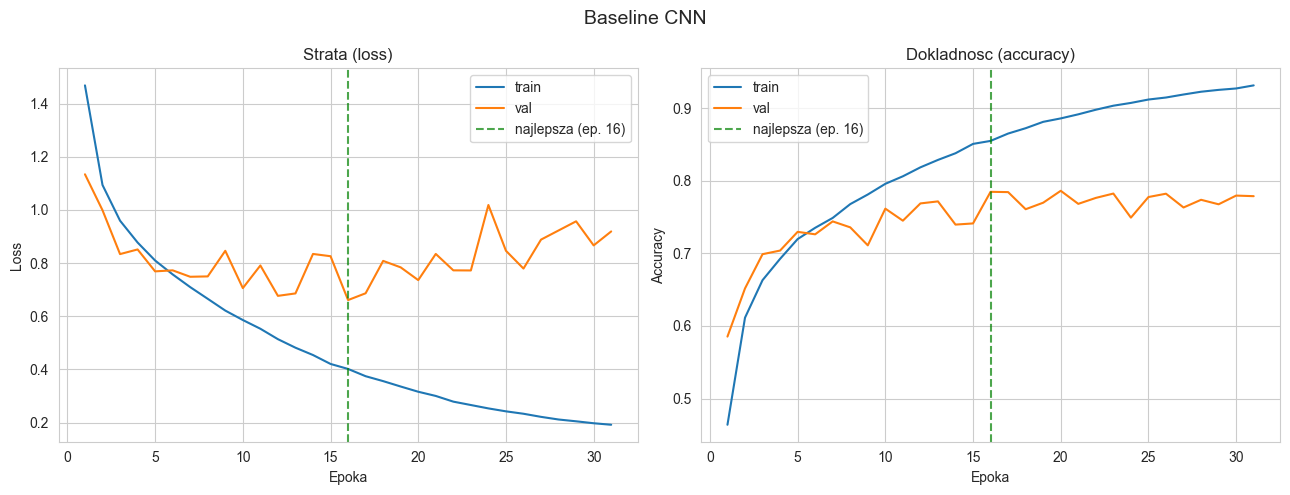

TEST — accuracy: 0.7811 | F1 macro: 0.7824


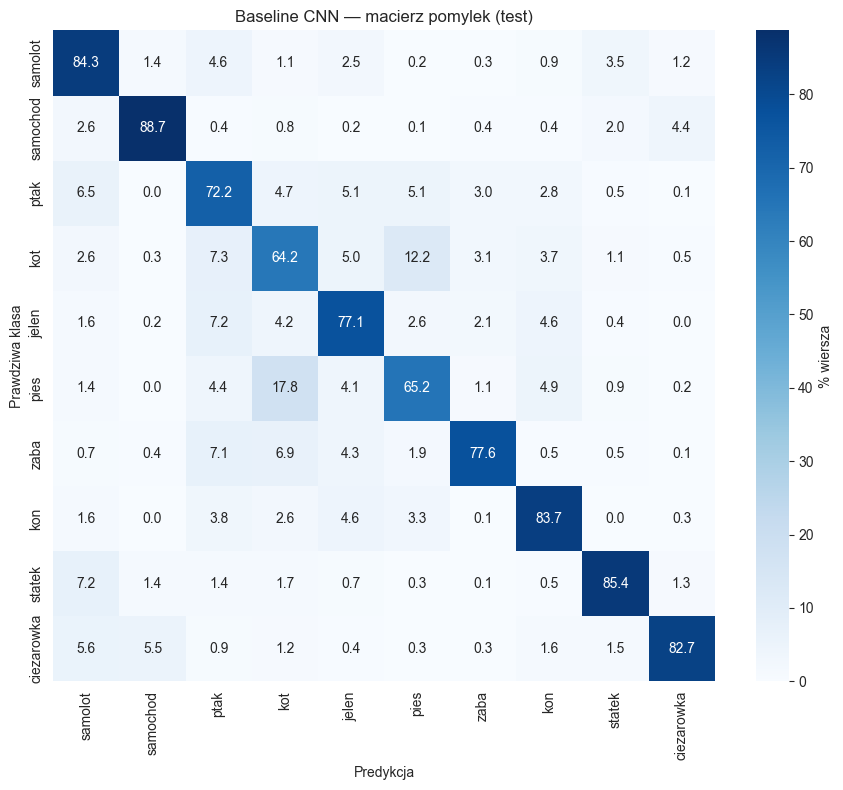

In [7]:
cp.plot_history(res_baseline["history"], title="Baseline CNN")
plt.show()

m = res_baseline["test_metrics"]
print(f"TEST — accuracy: {m['accuracy']:.4f} | F1 macro: {m['f1_macro']:.4f}")
cp.plot_confusion_matrix(m["y_true"], m["y_pred"],
                         title="Baseline CNN — macierz pomylek (test)")
plt.show()

### Wnioski — Etap 1

Surowy baseline (Adam `lr=0.001`, batch 128, bez augmentacji, normalizacji, schedulera
i label smoothingu) osiąga **78,1% accuracy na teście** (`val_acc` 78,5%, `test_f1` 0,782).

- Prosta sieć Conv-BN-ReLU okazuje się zaskakująco mocnym punktem startu — już bez żadnych
  optymalizacji.
- Model szybko się **przeucza**: najlepsza epoka to 16, a early stopping ucina trening na 31.
  `train_loss` spada dalej, ale `val_loss` zaczyna rosnąć — brak regularyzacji daje o sobie znać.
- To celowo „goły" punkt odniesienia. Kolejne etapy pokazują, ile dokłada każda pojedyncza
  technika (harmonogram LR, augmentacja, głębokość, skip connections).

## Etap 2 — Adam vs SGD (i rola harmonogramu LR)

**Pytanie badawcze:** który optymalizator lepiej radzi sobie z CIFAR-10 — i czy decyduje
sam optymalizator, czy harmonogram learning rate?

Żeby to rozdzielić, robimy małą **ablację 2×2**: {Adam, SGD} × {stały LR, CosineAnnealingLR}.
Wszystko inne stałe (batch 128, dropout 0.5, bez augmentacji, label smoothing 0.1, weight
decay 5e-4). Adam zawsze `lr=0.001`, SGD zawsze `lr=0.1` (momentum 0.9) — między krokiem A i B
zmienia się **tylko** harmonogram, więc efekt można jednoznacznie przypisać konkretnej zmianie.

Idziemy narracyjnie: najpierw surowe optymalizatory (stały LR), potem włączamy cosine obu.

### Krok A — surowe optymalizatory (stały LR)

Adam i SGD ze **stałym** learning rate i early stoppingiem (patience 15). To „domyślne"
ustawienie bez żadnego harmonogramu. Obserwuj zwłaszcza SGD: z wysokim, niegasnącym LR=0.1
łatwo o niestabilność (szarpiący się `val_loss`).

In [4]:
# Wspolna baza dla wszystkich 4 wariantow Etapu 2.
common2 = dict(
    arch="baseline", batch_size=128, dropout=0.5, augment=False,
    normalize=False, label_smoothing=0.1, weight_decay=5e-4,
    seed=42, num_workers=0,
)

# KROK A: staly LR + early stopping.
config_adam_const = {**common2, "optimizer": "adam", "lr": 0.001, "scheduler": "none",
                     "max_epochs": 50, "patience": 15}
config_sgd_const  = {**common2, "optimizer": "sgd",  "lr": 0.1,   "scheduler": "none",
                     "momentum": 0.9, "max_epochs": 50, "patience": 15}

res_adam_const = cp.run_experiment(config_adam_const, data, device, EXPERIMENTS_DIR,
                                   category="opt_const", evaluate_test=True)
res_sgd_const  = cp.run_experiment(config_sgd_const,  data, device, EXPERIMENTS_DIR,
                                   category="opt_const", evaluate_test=True)


=== opt_const/baseline_bs128_lr0.001_drop0.5_aug0 | parametry: 620,586 ===
Epoka   1/50 | lr 0.0010 | train_loss 1.6728 acc 0.4629 | val_loss 1.3720 acc 0.5948 *
Epoka   2/50 | lr 0.0010 | train_loss 1.3948 acc 0.6142 | val_loss 1.2971 acc 0.6480 *
Epoka   3/50 | lr 0.0010 | train_loss 1.2932 acc 0.6682 | val_loss 1.2025 acc 0.7002 *
Epoka   4/50 | lr 0.0010 | train_loss 1.2371 acc 0.6971 | val_loss 1.1255 acc 0.7378 *
Epoka   5/50 | lr 0.0010 | train_loss 1.1874 acc 0.7207 | val_loss 1.0953 acc 0.7518 *
Epoka   6/50 | lr 0.0010 | train_loss 1.1516 acc 0.7420 | val_loss 1.1868 acc 0.7080
Epoka   7/50 | lr 0.0010 | train_loss 1.1169 acc 0.7576 | val_loss 1.1797 acc 0.7068
Epoka   8/50 | lr 0.0010 | train_loss 1.0894 acc 0.7735 | val_loss 1.2081 acc 0.6992
Epoka   9/50 | lr 0.0010 | train_loss 1.0625 acc 0.7893 | val_loss 1.0798 acc 0.7590 *
Epoka  10/50 | lr 0.0010 | train_loss 1.0335 acc 0.8010 | val_loss 1.1596 acc 0.7198
Epoka  11/50 | lr 0.0010 | train_loss 1.0166 acc 0.8094 | val_

### Krok B — włączamy cosine obu optymalizatorom

Teraz oba dostają **CosineAnnealingLR na pełne 50 epok, bez early stoppingu** (harmonogram
musi dobiec do końca, żeby annealing zadziałał — checkpoint i tak po najniższym `val_loss`).
Zmieniamy względem kroku A tylko harmonogram LR, więc różnica w wyniku = wpływ cosine.

In [5]:
# KROK B: cosine, pelne 50 epok, bez early stoppingu.
config_adam_cos = {**common2, "optimizer": "adam", "lr": 0.001, "scheduler": "cosine",
                   "max_epochs": 50, "early_stopping": False}
config_sgd_cos  = {**common2, "optimizer": "sgd",  "lr": 0.1,   "scheduler": "cosine",
                   "momentum": 0.9, "max_epochs": 50, "early_stopping": False}

res_adam_cos = cp.run_experiment(config_adam_cos, data, device, EXPERIMENTS_DIR,
                                 category="opt_cosine", evaluate_test=True)
res_sgd_cos  = cp.run_experiment(config_sgd_cos,  data, device, EXPERIMENTS_DIR,
                                 category="opt_cosine", evaluate_test=True)


=== opt_cosine/baseline_bs128_lr0.001_drop0.5_aug0 | parametry: 620,586 ===
Epoka   1/50 | lr 0.0010 | train_loss 1.6728 acc 0.4629 | val_loss 1.3720 acc 0.5948 *
Epoka   2/50 | lr 0.0010 | train_loss 1.3934 acc 0.6145 | val_loss 1.2818 acc 0.6556 *
Epoka   3/50 | lr 0.0010 | train_loss 1.2923 acc 0.6673 | val_loss 1.2027 acc 0.7024 *
Epoka   4/50 | lr 0.0010 | train_loss 1.2350 acc 0.6971 | val_loss 1.1452 acc 0.7246 *
Epoka   5/50 | lr 0.0010 | train_loss 1.1853 acc 0.7226 | val_loss 1.0992 acc 0.7540 *
Epoka   6/50 | lr 0.0010 | train_loss 1.1463 acc 0.7430 | val_loss 1.1835 acc 0.7138
Epoka   7/50 | lr 0.0010 | train_loss 1.1104 acc 0.7607 | val_loss 1.1517 acc 0.7232
Epoka   8/50 | lr 0.0010 | train_loss 1.0816 acc 0.7771 | val_loss 1.2163 acc 0.7008
Epoka   9/50 | lr 0.0009 | train_loss 1.0506 acc 0.7931 | val_loss 1.0561 acc 0.7702 *
Epoka  10/50 | lr 0.0009 | train_loss 1.0229 acc 0.8066 | val_loss 1.1765 acc 0.7110
Epoka  11/50 | lr 0.0009 | train_loss 1.0016 acc 0.8184 | val

### Porównanie czterech wariantów

Zestawiamy krzywe uczenia i wyniki testowe. Czytamy to dwojako: **w pionie** (Adam vs SGD przy
tym samym harmonogramie) oraz **w poziomie** (co dał cosine każdemu z osobna).

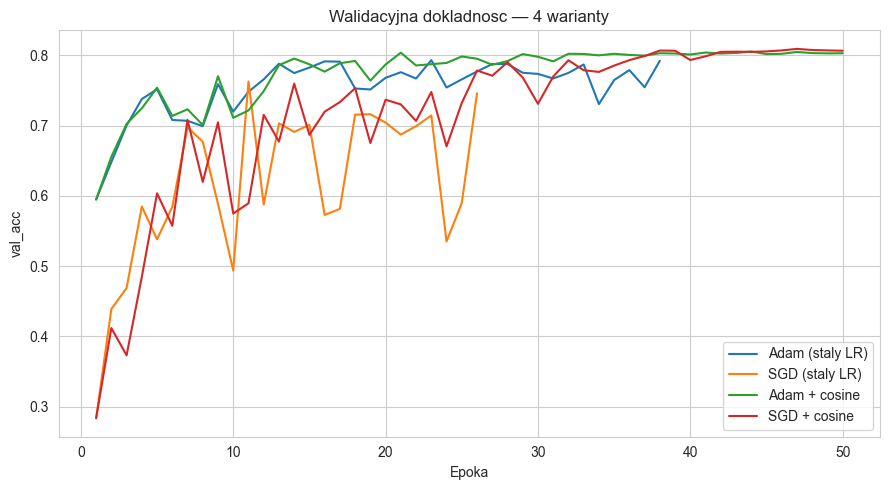

,wariant,test_acc,test_f1,best_epoch
0,Adam (staly LR),0.7869,0.7867,23
1,SGD (staly LR),0.7660,0.7663,11
2,Adam + cosine,0.7913,0.7900,21
3,SGD + cosine,0.8018,0.8014,49


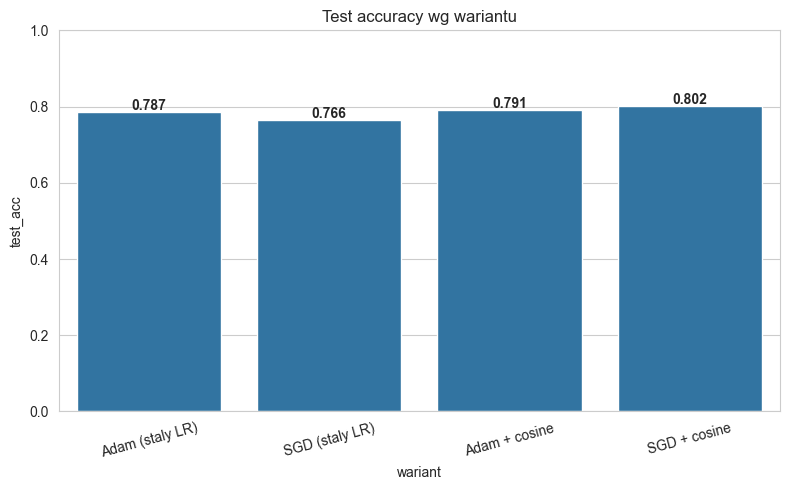

In [6]:
variants = [
    ("Adam (staly LR)", res_adam_const),
    ("SGD (staly LR)",  res_sgd_const),
    ("Adam + cosine",   res_adam_cos),
    ("SGD + cosine",    res_sgd_cos),
]

# Krzywe walidacyjnej dokladnosci.
plt.figure(figsize=(9, 5))
for name, res in variants:
    ep = range(1, len(res["history"]["val_acc"]) + 1)
    plt.plot(ep, res["history"]["val_acc"], label=name)
plt.title("Walidacyjna dokladnosc — 4 warianty")
plt.xlabel("Epoka"); plt.ylabel("val_acc"); plt.legend(); plt.tight_layout(); plt.show()

# Tabela + slupki test accuracy.
tab = pd.DataFrame([{
    "wariant": n,
    "test_acc": r["test_metrics"]["accuracy"],
    "test_f1": round(r["test_metrics"]["f1_macro"], 4),
    "best_epoch": r["history"]["best_epoch"],
} for n, r in variants])
display(tab)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=tab, x="wariant", y="test_acc")
for i, v in enumerate(tab["test_acc"]):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontweight="bold")
plt.xticks(rotation=15); plt.title("Test accuracy wg wariantu"); plt.ylim(0, 1)
plt.tight_layout(); plt.show()

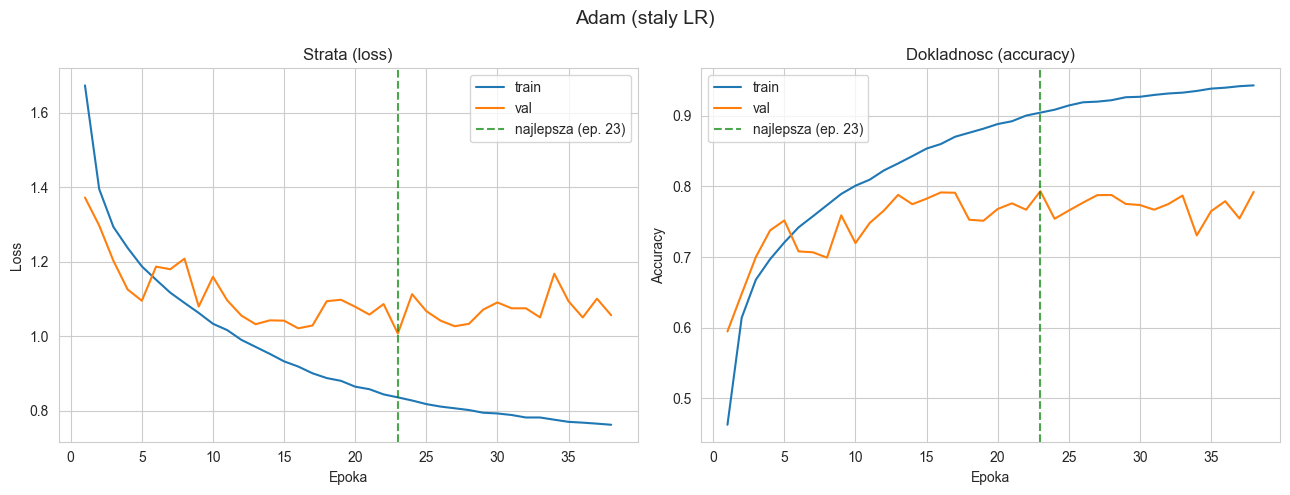

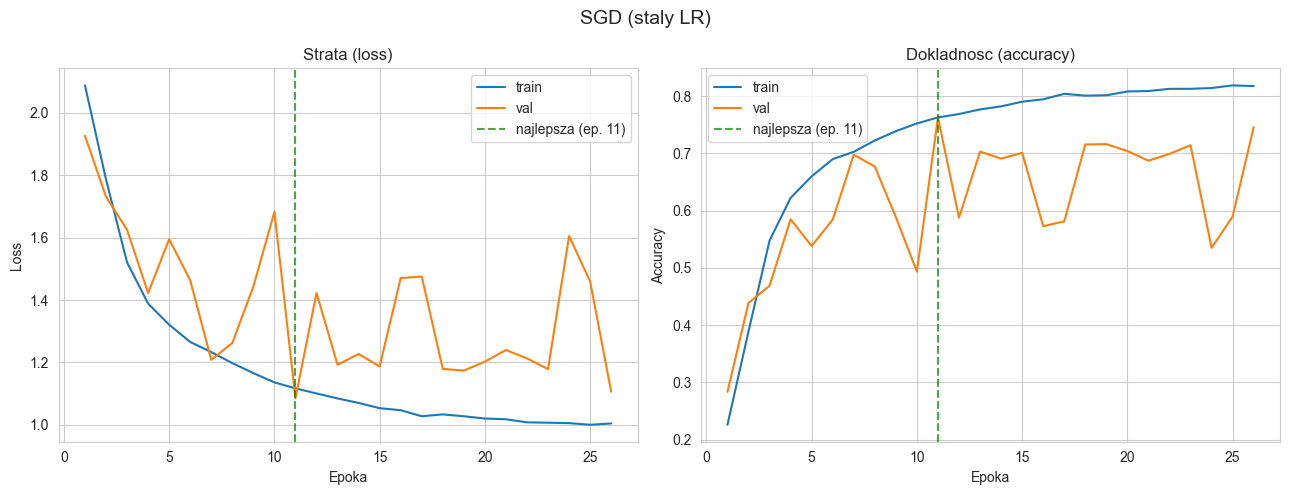

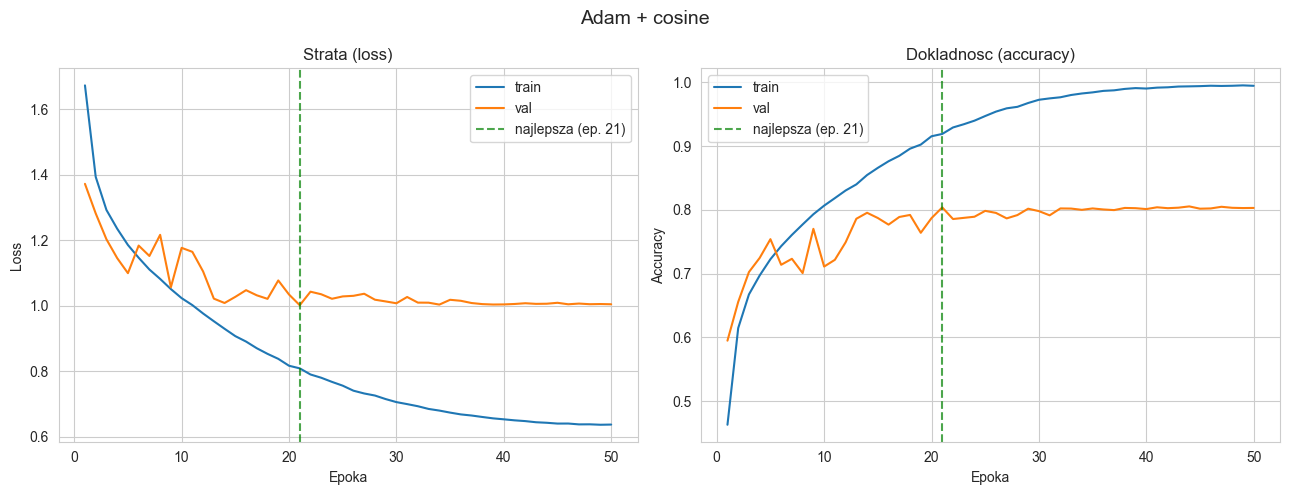

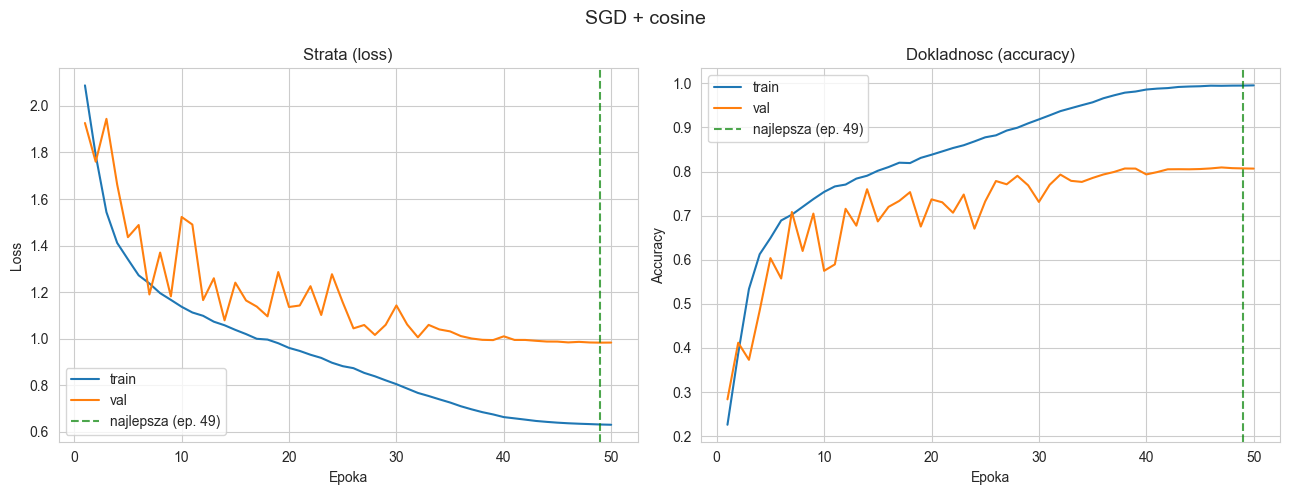

In [7]:
for name, res in [
    ("Adam (staly LR)", res_adam_const),
    ("SGD (staly LR)",  res_sgd_const),
    ("Adam + cosine",   res_adam_cos),
    ("SGD + cosine",    res_sgd_cos),
]:
    cp.plot_history(res["history"], title=name)
    plt.show()

### Wnioski — Etap 2

Wyniki testowe ablacji 2×2 (`{Adam, SGD} × {stały LR, cosine}`):

| Wariant | stały LR | + cosine |
|---|---|---|
| **Adam** (`lr=0.001`) | 78,7% | 79,1% |
| **SGD** (`lr=0.1`) | 76,6% | **80,2%** |

- **Krok A (stały LR):** na surowo wygrywa **Adam** (78,7% vs 76,6%). SGD z wysokim, niegasnącym
  `LR=0.1` jest niestabilny — early stopping wyłącza go już na 11. epoce, a `val_loss` (1,085)
  jest wyraźnie wyższy niż u Adama. Adaptacyjny krok Adama radzi sobie bez strojenia, czysty SGD
  z dużym LR — nie.
- **Krok B (cosine):** harmonogram pomógł obu, ale nierówno — Adam zyskał +0,4 pp, a SGD aż
  **+3,6 pp** i wyszedł na prowadzenie. SGD nie był gorszym optymalizatorem; brakowało mu jedynie
  malejącego learning rate.
- **Izolacja zmiennej:** między krokiem A i B zmienia się wyłącznie harmonogram LR, więc końcowa
  przewaga to zasługa **cosine annealingu**, a nie samego optymalizatora.
- Najlepszy wariant — **SGD + cosine (80,2%)** — wchodzi do grid searcha jako baza dalszych eksperymentów.

## Etap 3 — Grid Search (strojenie hiperparametrów)

**Pytanie badawcze:** która kombinacja hiperparametrów daje najlepsze wyniki na baseline?

Siatka 3 × 3 × 2 × 2 = **36 kombinacji** (`lr` × `batch_size` × `dropout` × `augment`).
Stałe: SGD (momentum 0.9), weight_decay 5e-4, label_smoothing 0.1, CosineAnnealingLR.
**Pełne 50 epok bez early stoppingu** — harmonogram cosine musi dobiec do końca, by zadziałał
annealing (early stopping ucinałby go za wcześnie). Checkpoint i tak po najniższym `val_loss`.
**Selekcja wyłącznie na walidacji** (test nietknięty).

> To długi etap, ale jest wznawialny

In [8]:
param_grid = {
    "lr": [0.01, 0.05, 0.1],
    "batch_size": [64, 128, 256],
    "dropout": [0.25, 0.5],
    "augment": [False, True],
}
fixed_config = dict(
    arch="baseline", optimizer="sgd", momentum=0.9, weight_decay=5e-4,
    label_smoothing=0.1, scheduler="cosine", normalize=False,
    max_epochs=50, patience=15, early_stopping=False, seed=42, num_workers=0,
)
grid_df = cp.run_grid_search(
    cp.build_baseline_cnn, param_grid, fixed_config, data, device,
    EXPERIMENTS_DIR, category="baseline",
)
grid_df.head(10)

Grid search: 36 kombinacji.

--- [1/36] {'lr': 0.01, 'batch_size': 64, 'dropout': 0.25, 'augment': False} ---

=== baseline/baseline_bs64_lr0.01_drop0.25_aug0 | parametry: 620,586 ===
Epoka   1/50 | lr 0.0100 | train_loss 1.5753 acc 0.5099 | val_loss 1.8950 acc 0.4096 *
Epoka   2/50 | lr 0.0100 | train_loss 1.2980 acc 0.6542 | val_loss 1.3123 acc 0.6522 *
Epoka   3/50 | lr 0.0100 | train_loss 1.1881 acc 0.7102 | val_loss 1.1498 acc 0.7250 *
Epoka   4/50 | lr 0.0099 | train_loss 1.1131 acc 0.7476 | val_loss 1.5594 acc 0.5844
Epoka   5/50 | lr 0.0098 | train_loss 1.0611 acc 0.7715 | val_loss 1.1458 acc 0.7224 *
Epoka   6/50 | lr 0.0098 | train_loss 1.0093 acc 0.7984 | val_loss 1.0858 acc 0.7528 *
Epoka   7/50 | lr 0.0096 | train_loss 0.9702 acc 0.8180 | val_loss 1.1139 acc 0.7406
Epoka   8/50 | lr 0.0095 | train_loss 0.9365 acc 0.8353 | val_loss 1.0140 acc 0.7966 *
Epoka   9/50 | lr 0.0094 | train_loss 0.8922 acc 0.8578 | val_loss 1.0254 acc 0.7856
Epoka  10/50 | lr 0.0092 | train_loss 0

,lr,batch_size,dropout,augment,val_accuracy,val_f1_macro,experiment_name
29,0.10,128,0.25,True,0.8716,0.871463,baseline_bs128_lr0.1_drop0.25_aug1
13,0.05,64,0.25,True,0.8716,0.871574,baseline_bs64_lr0.05_drop0.25_aug1
1,0.01,64,0.25,True,0.8706,0.870661,baseline_bs64_lr0.01_drop0.25_aug1
19,0.05,128,0.50,True,0.8696,0.869257,baseline_bs128_lr0.05_drop0.5_aug1
15,0.05,64,0.50,True,0.8692,0.868944,baseline_bs64_lr0.05_drop0.5_aug1
35,0.10,256,0.50,True,0.8682,0.868184,baseline_bs256_lr0.1_drop0.5_aug1
31,0.10,128,0.50,True,0.8676,0.867518,baseline_bs128_lr0.1_drop0.5_aug1
21,0.05,256,0.25,True,0.8670,0.866844,baseline_bs256_lr0.05_drop0.25_aug1
33,0.10,256,0.25,True,0.8670,0.866940,baseline_bs256_lr0.1_drop0.25_aug1
17,0.05,128,0.25,True,0.8668,0.867031,baseline_bs128_lr0.05_drop0.25_aug1


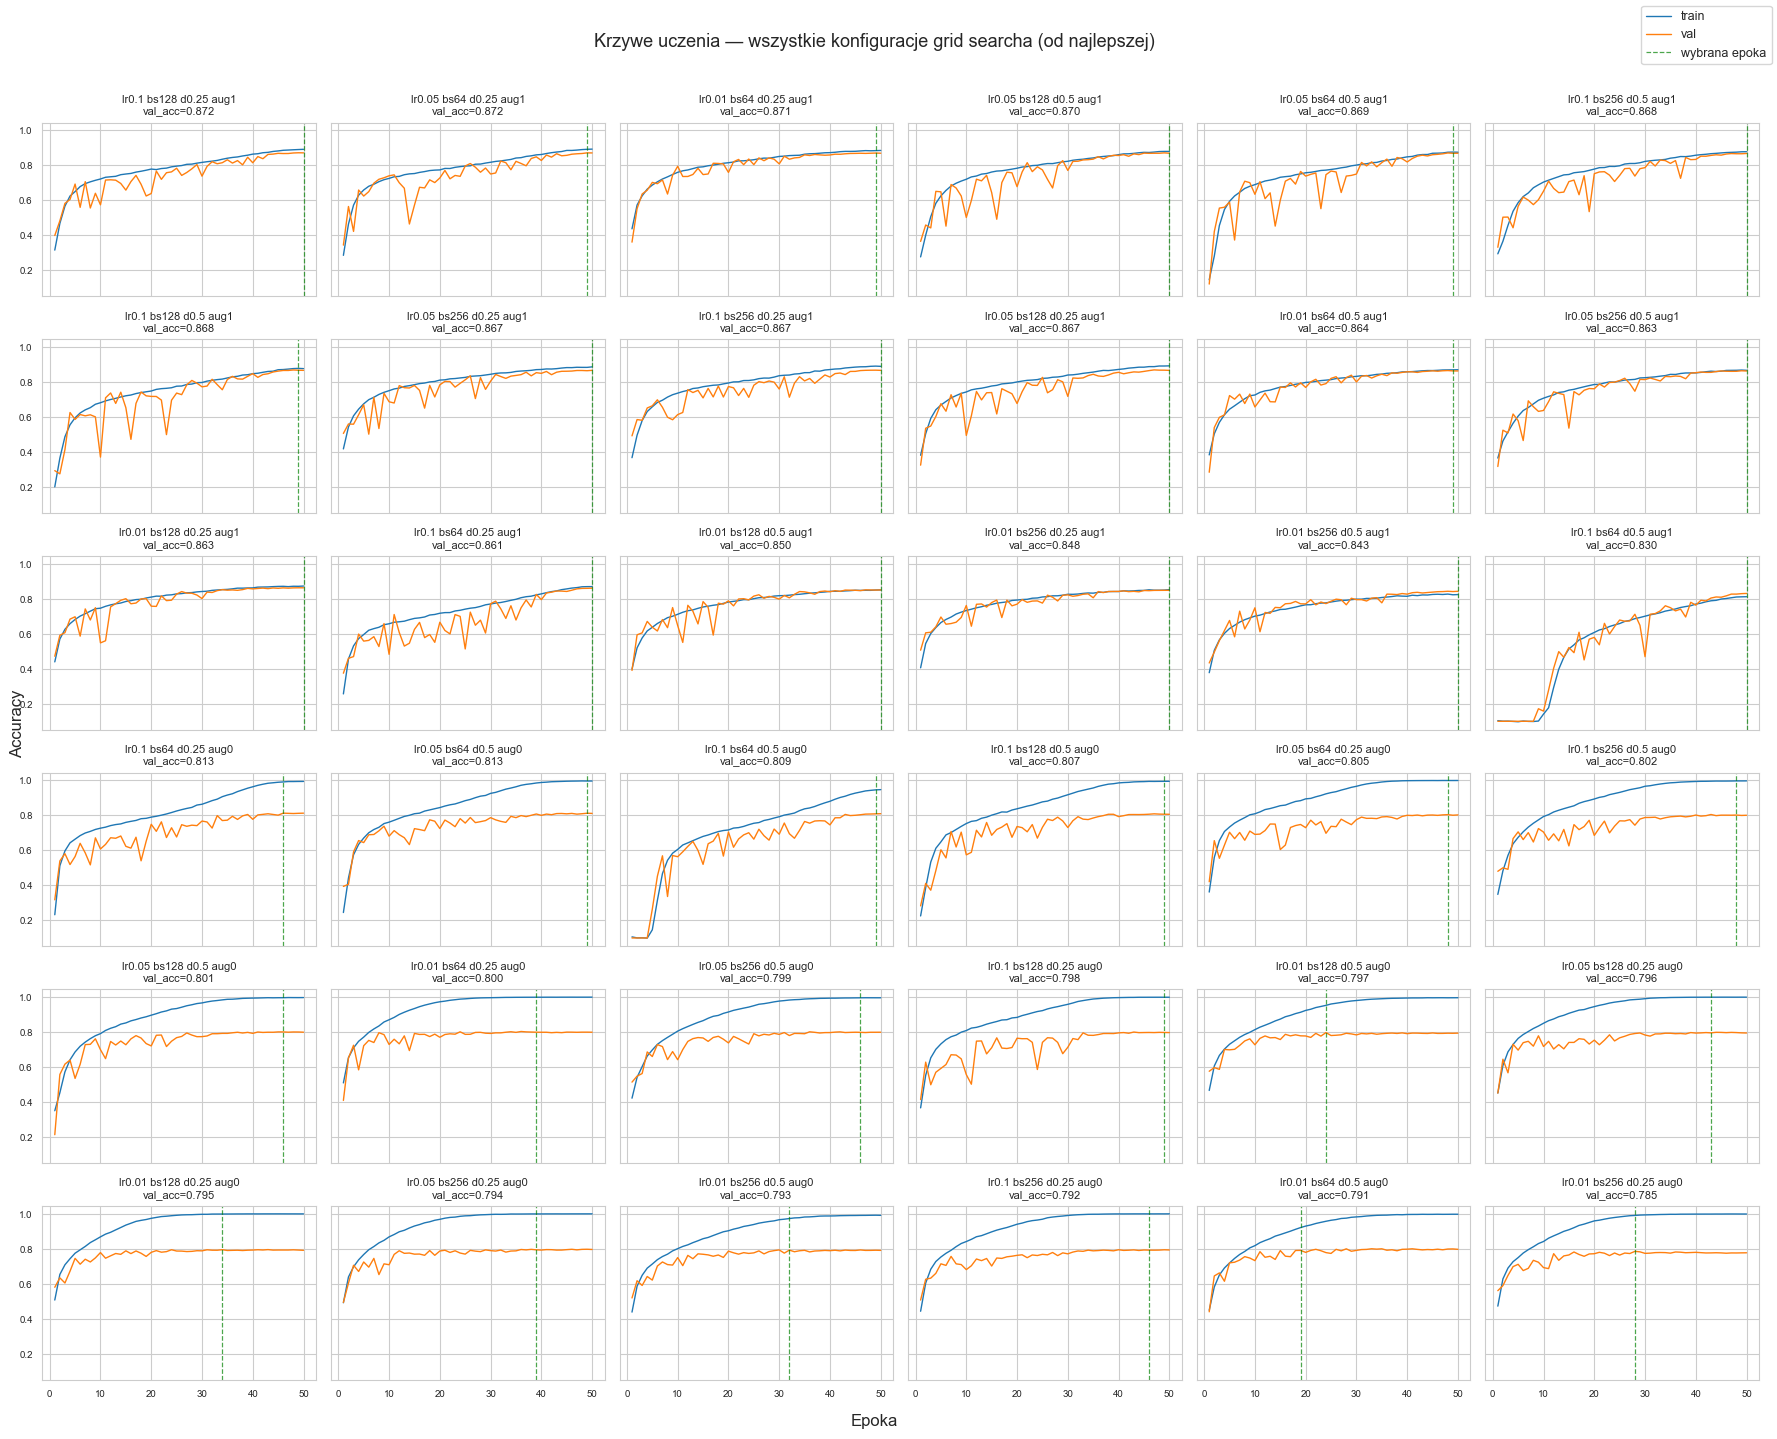

In [27]:
# Krzywe uczenia wszystkich 36 konfiguracji gridu, jedna obok drugiej.
# Czytamy history.csv z dysku; kolejnosc od najlepszej do najgorszej wg val_accuracy.
import math

# Wczytujemy wyniki gridu z dysku — dziala po resecie kernela, bez ponownego treningu.
grid_df = pd.read_csv(EXPERIMENTS_DIR / "tuning" / "grid_results.csv")

ranked = grid_df.sort_values("val_accuracy", ascending=False).reset_index(drop=True)
n = len(ranked)
ncols = 6
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 2.4 * nrows),
                        sharex=True, sharey=True)
axes = axes.flatten()

for ax, (_, row) in zip(axes, ranked.iterrows()):
    exp_dir = EXPERIMENTS_DIR / "baseline" / row["experiment_name"]
    hist = pd.read_csv(exp_dir / "history.csv")
    ax.plot(hist["epoch"], hist["train_acc"], label="train", lw=1)
    ax.plot(hist["epoch"], hist["val_acc"], label="val", lw=1)
# Wybrana epoka = ta z najnizszym val_loss (kryterium zapisu modelu).
    best_ep = int(hist.loc[hist["val_loss"].idxmin(), "epoch"])
    ax.axvline(best_ep, color="green", ls="--", lw=0.9, alpha=0.7, label="wybrana epoka")
    ax.set_title(
        f"lr{row['lr']} bs{row['batch_size']} d{row['dropout']} aug{int(row['augment'])}\n"
        f"val_acc={row['val_accuracy']:.3f}",
        fontsize=8,
    )
    ax.tick_params(labelsize=7)

# Ukryj puste osie, gdyby siatka nie wypelnila sie do konca.
for ax in axes[n:]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize=9)
fig.suptitle("Krzywe uczenia — wszystkie konfiguracje grid searcha (od najlepszej)", fontsize=13)
fig.supxlabel("Epoka"); fig.supylabel("Accuracy")
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

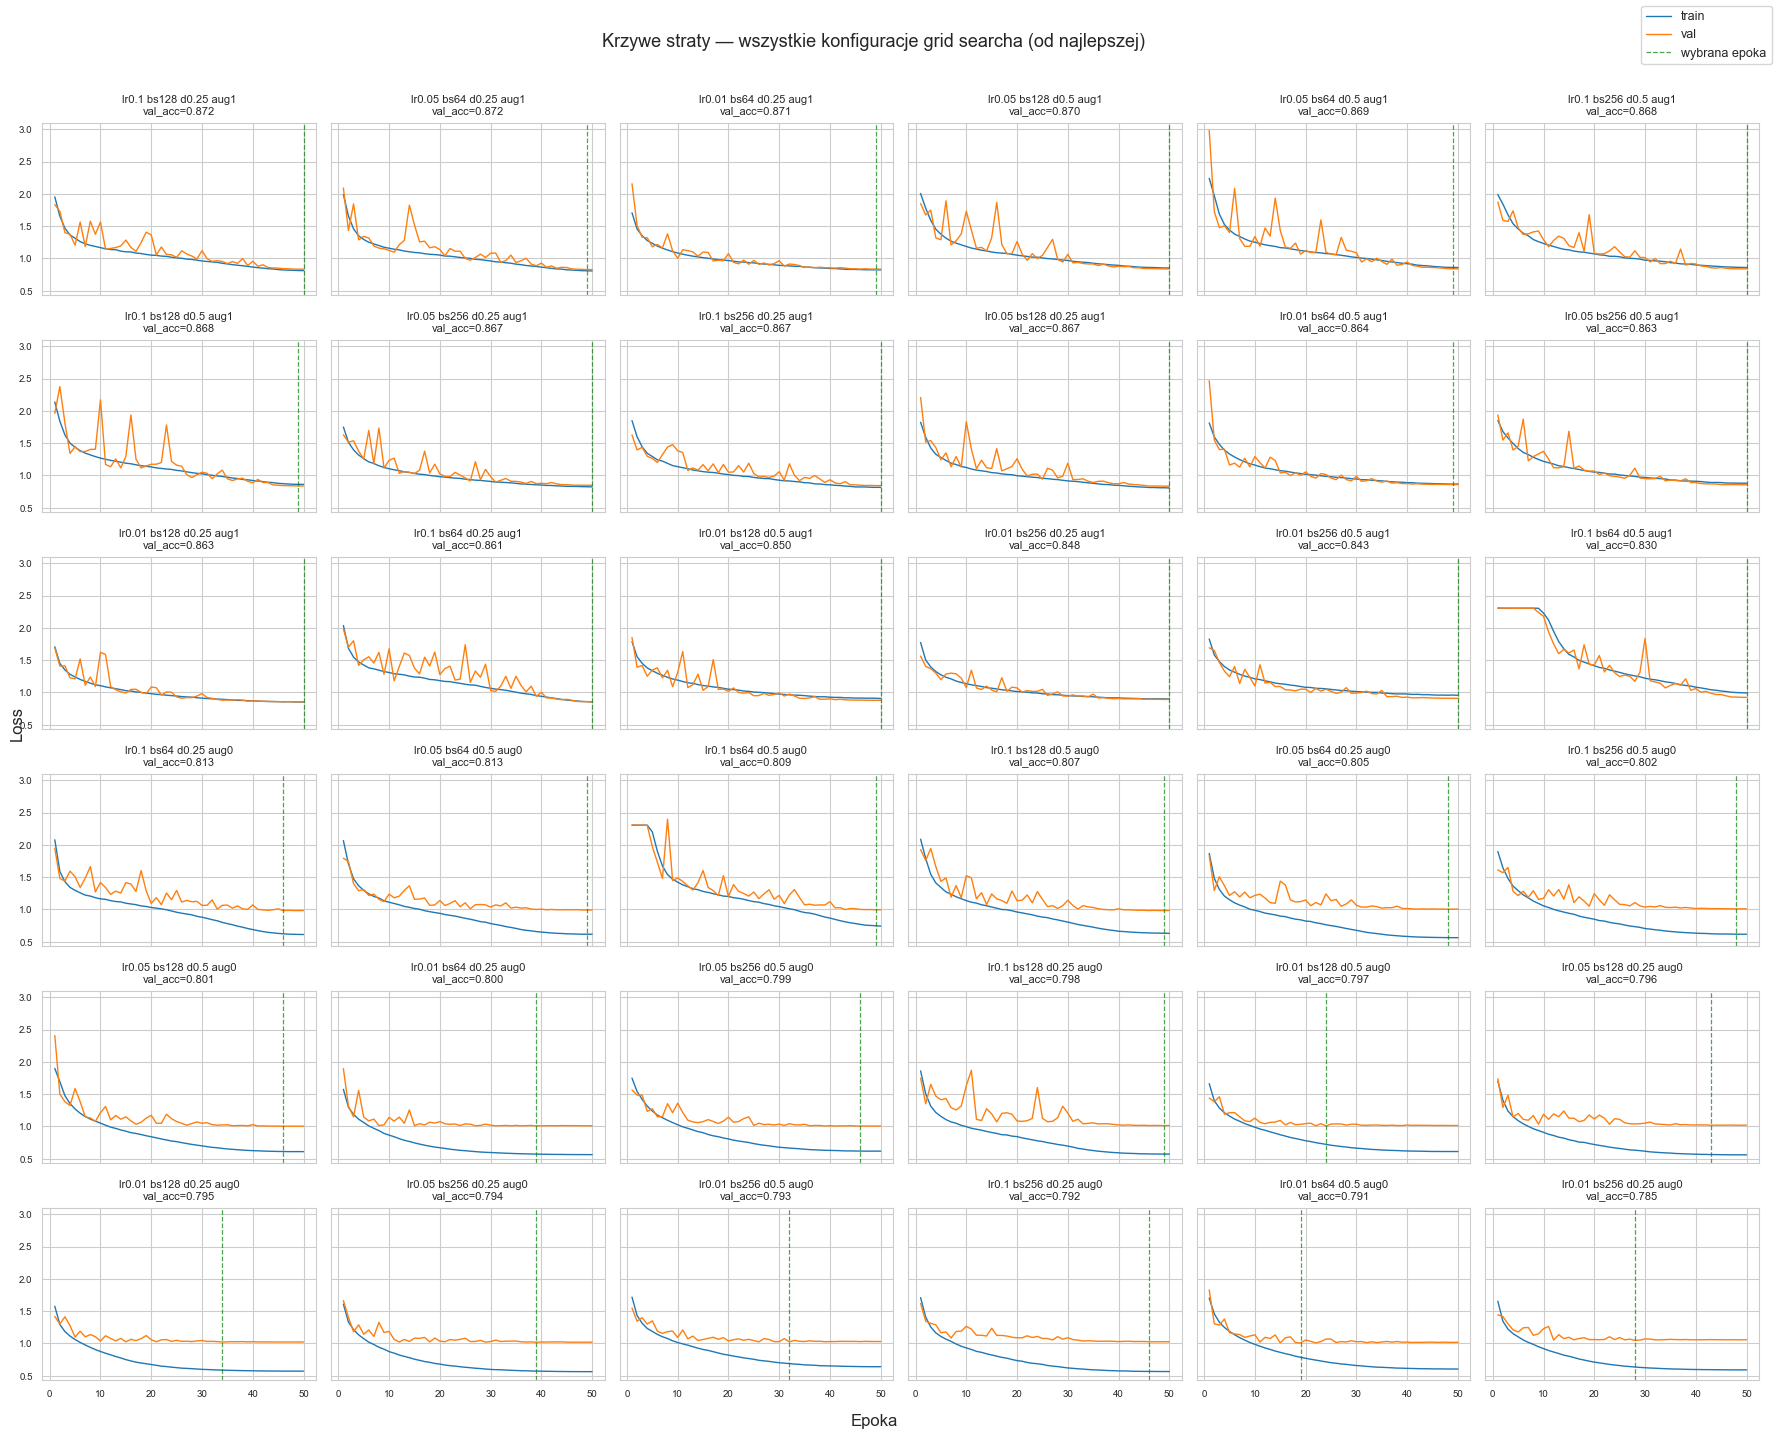

In [26]:
# Krzywe straty (train_loss / val_loss) wszystkich 36 konfiguracji gridu.
import math

# Wczytujemy wyniki gridu z dysku — dziala po resecie kernela, bez ponownego treningu.
grid_df = pd.read_csv(EXPERIMENTS_DIR / "tuning" / "grid_results.csv")

ranked = grid_df.sort_values("val_accuracy", ascending=False).reset_index(drop=True)
n = len(ranked)
ncols = 6
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 2.4 * nrows),
                        sharex=True, sharey=True)
axes = axes.flatten()

for ax, (_, row) in zip(axes, ranked.iterrows()):
    exp_dir = EXPERIMENTS_DIR / "baseline" / row["experiment_name"]
    hist = pd.read_csv(exp_dir / "history.csv")
    ax.plot(hist["epoch"], hist["train_loss"], label="train", lw=1)
    ax.plot(hist["epoch"], hist["val_loss"], label="val", lw=1)
# Wybrana epoka = ta z najnizszym val_loss (kryterium zapisu modelu).
    best_ep = int(hist.loc[hist["val_loss"].idxmin(), "epoch"])
    ax.axvline(best_ep, color="green", ls="--", lw=0.9, alpha=0.7, label="wybrana epoka")
    ax.set_title(
        f"lr{row['lr']} bs{row['batch_size']} d{row['dropout']} aug{int(row['augment'])}\n"
        f"val_acc={row['val_accuracy']:.3f}",
        fontsize=8,
    )
    ax.tick_params(labelsize=7)

for ax in axes[n:]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize=9)
fig.suptitle("Krzywe straty — wszystkie konfiguracje grid searcha (od najlepszej)", fontsize=13)
fig.supxlabel("Epoka"); fig.supylabel("Loss")
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

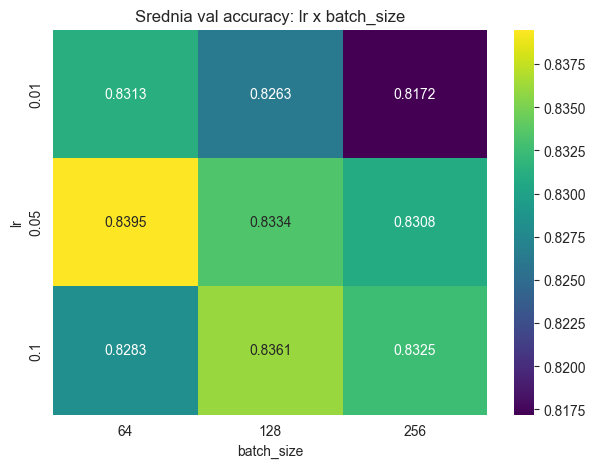

In [9]:
# Heatmapa: srednie val accuracy dla lr x batch_size (usrednione po dropout i augment).
pivot = grid_df.pivot_table(index="lr", columns="batch_size",
                            values="val_accuracy", aggfunc="mean")
plt.figure(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="viridis")
plt.title("Srednia val accuracy: lr x batch_size")
plt.ylabel("lr"); plt.xlabel("batch_size")
plt.show()

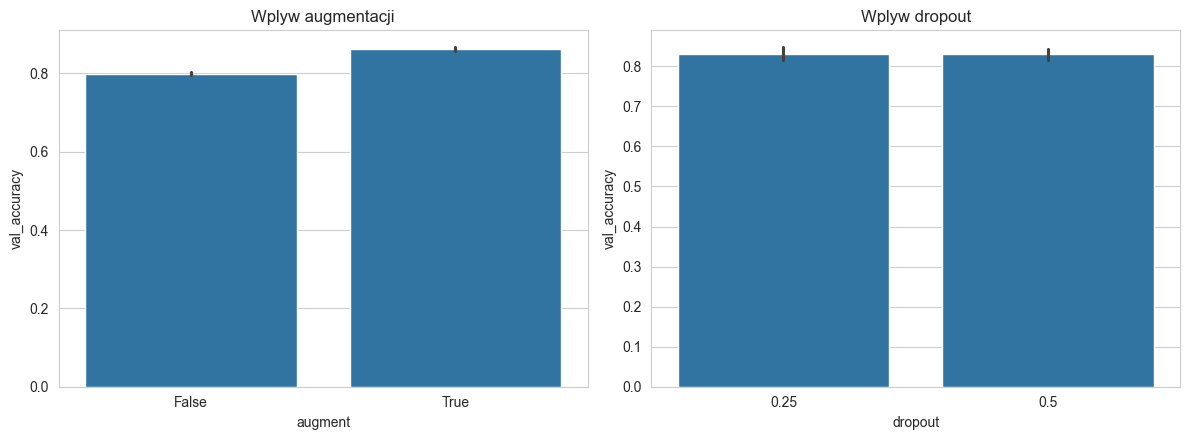

In [10]:
# Osobno wplyw augmentacji i dropout na val accuracy.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=grid_df, x="augment", y="val_accuracy", ax=axes[0])
axes[0].set_title("Wplyw augmentacji")
sns.barplot(data=grid_df, x="dropout", y="val_accuracy", ax=axes[1])
axes[1].set_title("Wplyw dropout")
plt.tight_layout(); plt.show()

In [11]:
import json
with open(EXPERIMENTS_DIR / "tuning" / "best_config.json", encoding="utf-8") as f:
    best_config = json.load(f)
print("Najlepsza konfiguracja z grid searcha:")
for k in ("lr", "batch_size", "dropout", "augment"):
    print(f"  {k}: {best_config[k]}")

Najlepsza konfiguracja z grid searcha:
  lr: 0.1
  batch_size: 128
  dropout: 0.25
  augment: True


In [12]:
# Najlepszy baseline z gridu — ewaluacja na zbiorze TESTOWYM (bez przetrenowywania).
best_name = cp.make_experiment_name(best_config)
best_dir = EXPERIMENTS_DIR / "baseline" / best_name
best_model = cp.load_trained_model(best_dir / "model.pt", "baseline",
                                   best_config["dropout"], device)
_, _, test_loader = cp.make_dataloaders(
    *data, batch_size=best_config["batch_size"],
    augment=best_config["augment"], normalize=best_config["normalize"],
)
baseline_best_test = cp.evaluate_model(best_model, test_loader, device)
print(f"Najlepszy baseline (tuned) -> TEST acc {baseline_best_test['accuracy']:.4f} "
      f"| F1 macro {baseline_best_test['f1_macro']:.4f}")

Najlepszy baseline (tuned) -> TEST acc 0.8637 | F1 macro 0.8633


### Wnioski — Etap 3

36 konfiguracji (SGD + cosine), selekcja wyłącznie po najniższym `val_loss`. Najlepsza:
**`lr=0.1`, `batch_size=128`, `dropout=0.25`, `augment=ON`** → `val_acc` **87,2%**, `val_f1` 0,871
(ta konfiguracja zostaje przeniesiona do Etapów 4–5).

- **Augmentacja to zdecydowanie najważniejszy czynnik.** Konfiguracje z `augment=ON` skupiają się
  w okolicy 84–87% `val_acc`, te bez augmentacji — 79–81%. Skok rzędu **+6–7 pp**, większy niż wpływ
  wszystkich pozostałych hiperparametrów razem wziętych.
- **Dropout:** przy włączonej augmentacji niższy `dropout=0.25` bije `0.5` — augmentacja już
  regularyzuje, a mocny dropout dodatkowo „dusi" sieć i zaniża wynik.
- **Learning rate:** `0.05` i `0.1` działają najlepiej; dzięki cosine wybór LR jest mało wrażliwy
  (wszystkie warianty zbiegają podobnie).
- **Batch size:** czynnik drugorzędny — `64` minimalnie lepszy, ale `128` w pełni konkurencyjny
  i wybrany ze względu na szybszy trening.
- Nastrojony baseline (~87% `val`) to **+~9 pp** względem surowego baseline'u z Etapu 1 (78%) —
  poprawa niemal w całości dzięki augmentacji.
- Najtrudniejsze klasy (per-class `val_f1`): **kot** 0,76 i **pies** 0,80; najłatwiejsze — pojazdy
  (samochód 0,93, statek 0,93, ciężarówka 0,93).

## Etap 4 — VGG-like

**Pytanie badawcze:** co daje sama głębokość sieci, bez skip connections?

Bierzemy najlepszą konfigurację z grid searcha (przenosimy `lr`, `batch_size`, `augment`
oraz `dropout`) i włączamy standaryzację per-kanał (`normalize=True`). Trenujemy dłużej — pełne 200 epok z harmonogramem cosine, bez early stoppingu (wyłączamy je celowo, by learning rate zdążył opaść niemal do zera; najlepszy model i tak zapisujemy po najniższej stracie walidacyjnej).

In [14]:
config_vgg = dict(
    arch="vgg_like",
    optimizer="sgd", momentum=0.9, weight_decay=5e-4,
    label_smoothing=0.1, scheduler="cosine",
    lr=best_config["lr"], batch_size=best_config["batch_size"],
    augment=best_config["augment"], dropout=best_config["dropout"],
    normalize=True,                 # standaryzacja per-kanal wlaczona od tego etapu
    max_epochs=200, patience=20, seed=42, num_workers=0,
    early_stopping=False
)
res_vgg = cp.run_experiment(config_vgg, data, device, EXPERIMENTS_DIR,
                            category="vgg_like", evaluate_test=True)
print("Parametry VGG-like:", f"{res_vgg['num_params']:,}",
      "| baseline:", f"{res_baseline['num_params']:,}")


=== vgg_like/vgg_like_bs128_lr0.1_drop0.25_aug1 | parametry: 3,968,202 ===
Epoka   1/200 | lr 0.1000 | train_loss 1.8769 acc 0.3493 | val_loss 1.6303 acc 0.4902 *
Epoka   2/200 | lr 0.1000 | train_loss 1.5410 acc 0.5281 | val_loss 1.5653 acc 0.5184 *
Epoka   3/200 | lr 0.1000 | train_loss 1.3367 acc 0.6298 | val_loss 1.2785 acc 0.6574 *
Epoka   4/200 | lr 0.0999 | train_loss 1.2155 acc 0.6899 | val_loss 1.1729 acc 0.7094 *
Epoka   5/200 | lr 0.0999 | train_loss 1.1180 acc 0.7374 | val_loss 1.6175 acc 0.5512
Epoka   6/200 | lr 0.0998 | train_loss 1.0627 acc 0.7650 | val_loss 1.1808 acc 0.7054
Epoka   7/200 | lr 0.0998 | train_loss 1.0279 acc 0.7801 | val_loss 1.1232 acc 0.7320 *
Epoka   8/200 | lr 0.0997 | train_loss 0.9985 acc 0.7944 | val_loss 1.0026 acc 0.7878 *
Epoka   9/200 | lr 0.0996 | train_loss 0.9795 acc 0.8012 | val_loss 1.1149 acc 0.7490
Epoka  10/200 | lr 0.0995 | train_loss 0.9546 acc 0.8111 | val_loss 1.0253 acc 0.7764
Epoka  11/200 | lr 0.0994 | train_loss 0.9392 acc 0.

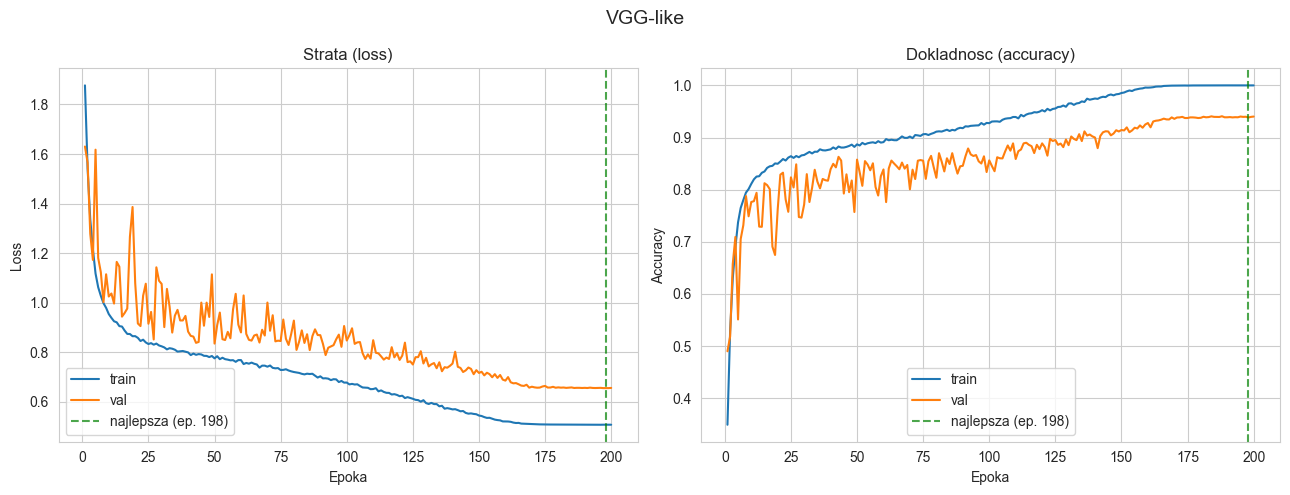

TEST — accuracy: 0.9383 | F1 macro: 0.9382


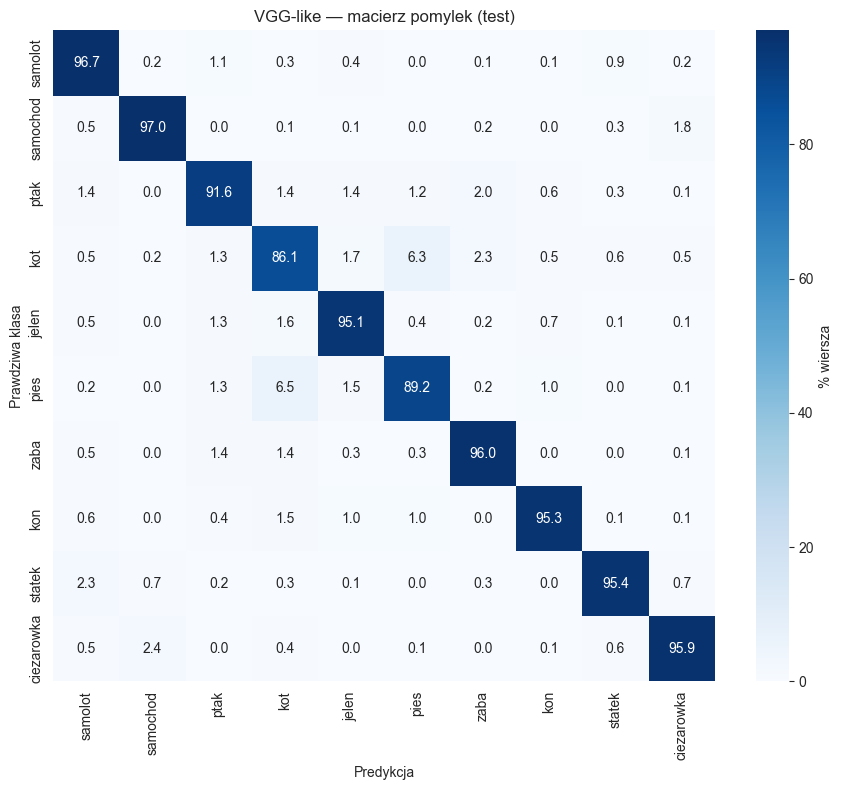

In [15]:
cp.plot_history(res_vgg["history"], title="VGG-like")
plt.show()
m = res_vgg["test_metrics"]
print(f"TEST — accuracy: {m['accuracy']:.4f} | F1 macro: {m['f1_macro']:.4f}")
cp.plot_confusion_matrix(m["y_true"], m["y_pred"],
                         title="VGG-like — macierz pomylek (test)")
plt.show()

### Wnioski — Etap 4

VGG-like (3,97 mln parametrów, `normalize=ON`, 200 epok cosine): **test_acc 93,8%**, `test_f1` 0,938,
najlepsza epoka 198.

- Sama **głębokość** (bez skip connections) dała **+~6–7 pp** względem nastrojonego baseline'u
  (~87% → 93,8%) — więcej warstw splotowych to bogatsze, hierarchiczne cechy.
- Model uczy się praktycznie do końca harmonogramu (best epoch 198/200): głębsza sieć potrzebuje
  pełnych 200 epok i wygaszania LR, by w pełni dojść.
- Per-class: najtrudniejszy nadal **kot** (`f1` 0,86) i **pies** (0,90), pozostałe klasy >0,92.
- **Ograniczenie:** dalsze pogłębianie czystej sieci VGG napotyka problem zanikającego gradientu —
  stąd skip connections w kolejnym etapie.

## Etap 5 — ResNet-like

**Pytanie badawcze:** czy skip connections przełamują ograniczenia głębokich sieci?

Intuicja: w bardzo głębokich sieciach gradient potrafi „zanikać" w drodze do wczesnych
warstw. Połączenie skip (ang. *residual connection*) tworzy „autostradę dla gradientu" — wyjście bloku to
`F(x) + x`, więc gradient ma bezpośrednią ścieżkę wstecz. Dzięki temu można trenować
znacznie głębsze sieci.

Konfiguracja jak dla VGG (lr/bs/aug z gridu, normalize ON), ale **dropout = 0** —
w tej architekturze rolę regularyzatora pełni BatchNorm.

In [16]:
config_resnet = dict(
    arch="resnet_like",
    optimizer="sgd", momentum=0.9, weight_decay=5e-4,
    label_smoothing=0.1, scheduler="cosine",
    lr=best_config["lr"], batch_size=best_config["batch_size"],
    augment=best_config["augment"],
    dropout=0.0,                    # w ResNecie regularyzuje BatchNorm
    normalize=True,
    max_epochs=200, patience=20, seed=42, num_workers=0,
    early_stopping=False
)
res_resnet = cp.run_experiment(config_resnet, data, device, EXPERIMENTS_DIR,
                               category="resnet_like", evaluate_test=True)
print("Parametry ResNet-inspired:", f"{res_resnet['num_params']:,}")


=== resnet_like/resnet_like_bs128_lr0.1_drop0.0_aug1 | parametry: 11,173,962 ===
Epoka   1/200 | lr 0.1000 | train_loss 2.0230 acc 0.3096 | val_loss 1.7435 acc 0.4078 *
Epoka   2/200 | lr 0.1000 | train_loss 1.6224 acc 0.4769 | val_loss 1.5154 acc 0.5204 *
Epoka   3/200 | lr 0.1000 | train_loss 1.4466 acc 0.5709 | val_loss 1.3749 acc 0.5998 *
Epoka   4/200 | lr 0.0999 | train_loss 1.2977 acc 0.6420 | val_loss 1.4873 acc 0.5594
Epoka   5/200 | lr 0.0999 | train_loss 1.2067 acc 0.6864 | val_loss 1.3455 acc 0.6262 *
Epoka   6/200 | lr 0.0998 | train_loss 1.1118 acc 0.7294 | val_loss 1.1697 acc 0.7072 *
Epoka   7/200 | lr 0.0998 | train_loss 1.0342 acc 0.7670 | val_loss 1.0385 acc 0.7654 *
Epoka   8/200 | lr 0.0997 | train_loss 0.9781 acc 0.7909 | val_loss 1.1551 acc 0.7250
Epoka   9/200 | lr 0.0996 | train_loss 0.9410 acc 0.8086 | val_loss 0.9873 acc 0.7878 *
Epoka  10/200 | lr 0.0995 | train_loss 0.9235 acc 0.8153 | val_loss 0.9531 acc 0.8074 *
Epoka  11/200 | lr 0.0994 | train_loss 0.9

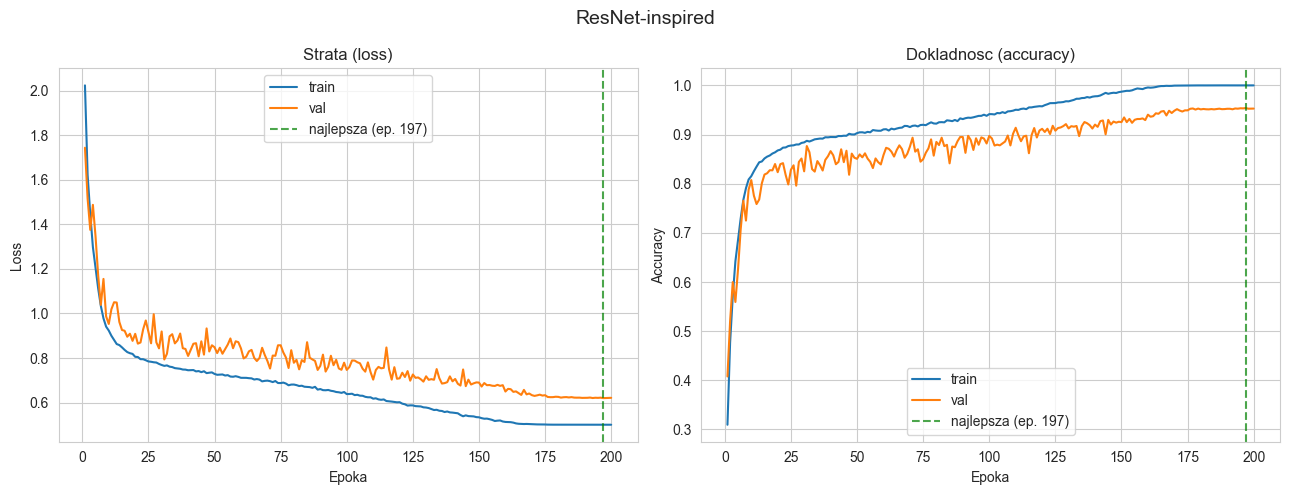

TEST — accuracy: 0.9519 | F1 macro: 0.9519


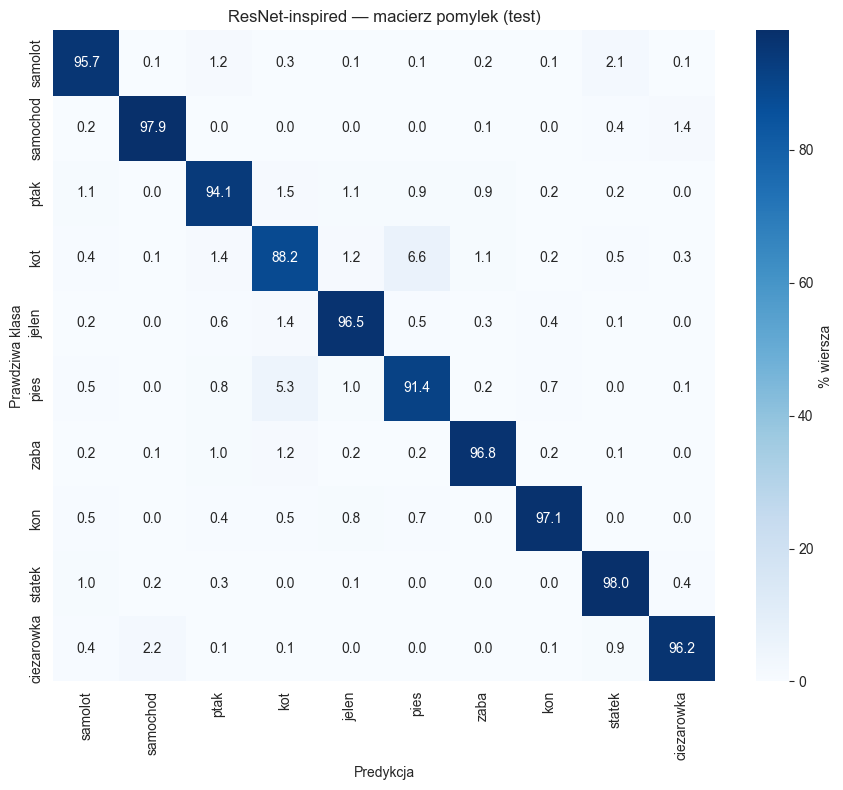

In [17]:
cp.plot_history(res_resnet["history"], title="ResNet-inspired")
plt.show()
m = res_resnet["test_metrics"]
print(f"TEST — accuracy: {m['accuracy']:.4f} | F1 macro: {m['f1_macro']:.4f}")
cp.plot_confusion_matrix(m["y_true"], m["y_pred"],
                         title="ResNet-inspired — macierz pomylek (test)")
plt.show()

### Wnioski — Etap 5

ResNet-like (11,17 mln parametrów, `dropout=0`, BatchNorm jako regularyzator, 200 epok):
**test_acc 95,2%**, `test_f1` 0,952, najlepsza epoka 197.

- **Skip connections** dały **+1,4 pp** względem VGG-like (93,8% → 95,2%) — „autostrada dla gradientu"
  pozwala skutecznie trenować głębszą sieć.
- Zysk jest **realny, ale malejący**: pierwsze +~6 pp dała głębokość (baseline → VGG), kolejne +1,4 pp
  skip connections. Koszt tej poprawy to **~2,8× więcej parametrów** (11,17 mln vs 3,97 mln).
- Per-class: **kot** (0,89) i **pies** (0,91) wciąż najsłabsze, ale wyraźnie podciągnięte;
  7 z 10 klas przekracza 0,96.
- Brak dropoutu nie zaszkodził — **BatchNorm + augmentacja** w zupełności wystarczają jako regularyzacja.

## Etap 6 — Porównanie wszystkich modeli

Zestawiamy finalne wyniki testowe trzech architektur i patrzymy, które klasy są
najtrudniejsze.

In [18]:
summary = pd.read_csv(EXPERIMENTS_DIR / "results_summary.csv")
summary.tail(10)

,experiment_name,arch,batch_size,lr,dropout,augment,optimizer,scheduler,normalize,label_smoothing,weight_decay,num_params,best_epoch,epochs_trained,early_stopped,best_val_loss,val_accuracy,val_f1_macro,test_accuracy,test_f1_macro,timestamp
33,baseline_bs128_lr0.1_drop0.25_aug0,baseline,128,0.1,0.25,0,sgd,cosine,0,0.1,0.0005,620586,49,50,True,1.0142,0.7980,0.7977,NaN,NaN,2026-06-07 20:28:19
34,baseline_bs128_lr0.1_drop0.25_aug1,baseline,128,0.1,0.25,1,sgd,cosine,0,0.1,0.0005,620586,50,50,False,0.8339,0.8716,0.8715,NaN,NaN,2026-06-07 20:35:06
35,baseline_bs128_lr0.1_drop0.5_aug0,baseline,128,0.1,0.50,0,sgd,cosine,0,0.1,0.0005,620586,49,50,False,0.9831,0.8070,0.8070,NaN,NaN,2026-06-07 20:38:00
36,baseline_bs128_lr0.1_drop0.5_aug1,baseline,128,0.1,0.50,1,sgd,cosine,0,0.1,0.0005,620586,49,50,False,0.8371,0.8676,0.8675,NaN,NaN,2026-06-07 20:44:41
37,baseline_bs256_lr0.1_drop0.25_aug0,baseline,256,0.1,0.25,0,sgd,cosine,0,0.1,0.0005,620586,46,50,True,1.0259,0.7924,0.7928,NaN,NaN,2026-06-07 20:46:31
38,baseline_bs256_lr0.1_drop0.25_aug1,baseline,256,0.1,0.25,1,sgd,cosine,0,0.1,0.0005,620586,50,50,False,0.8429,0.8670,0.8669,NaN,NaN,2026-06-07 20:52:01
39,baseline_bs256_lr0.1_drop0.5_aug0,baseline,256,0.1,0.50,0,sgd,cosine,0,0.1,0.0005,620586,48,50,False,1.0089,0.8022,0.8025,NaN,NaN,2026-06-07 20:53:52
40,baseline_bs256_lr0.1_drop0.5_aug1,baseline,256,0.1,0.50,1,sgd,cosine,0,0.1,0.0005,620586,50,50,False,0.8384,0.8682,0.8682,NaN,NaN,2026-06-07 20:59:24
41,vgg_like_bs128_lr0.1_drop0.25_aug1,vgg_like,128,0.1,0.25,1,sgd,cosine,1,0.1,0.0005,3968202,198,200,True,0.6557,0.9384,0.9386,0.9383,0.9382,2026-06-07 22:13:07
42,resnet_like_bs128_lr0.1_drop0.0_aug1,resnet_like,128,0.1,0.00,1,sgd,cosine,1,0.1,0.0005,11173962,197,200,True,0.6205,0.9538,0.9538,0.9519,0.9519,2026-06-07 23:32:08


,model,test_accuracy,test_f1_macro,params
0,Baseline (tuned),0.8637,0.863275,620586
1,VGG-like,0.9383,0.938246,3968202
2,ResNet-inspired,0.9519,0.951857,11173962


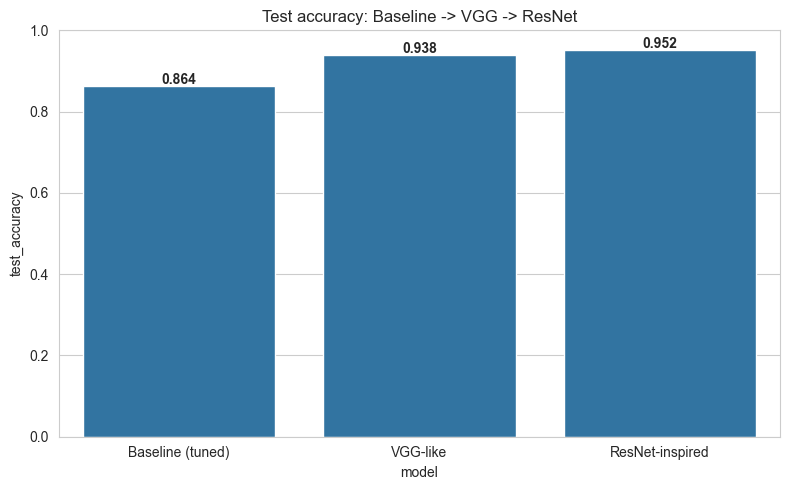

In [19]:
# Finalne wyniki testowe trzech architektur (baseline w wersji nastrojonej z gridu).
final = pd.DataFrame([
    {"model": "Baseline (tuned)", "test_accuracy": baseline_best_test["accuracy"],
     "test_f1_macro": baseline_best_test["f1_macro"], "params": res_baseline["num_params"]},
    {"model": "VGG-like", "test_accuracy": res_vgg["test_metrics"]["accuracy"],
     "test_f1_macro": res_vgg["test_metrics"]["f1_macro"], "params": res_vgg["num_params"]},
    {"model": "ResNet-inspired", "test_accuracy": res_resnet["test_metrics"]["accuracy"],
     "test_f1_macro": res_resnet["test_metrics"]["f1_macro"], "params": res_resnet["num_params"]},
])
display(final)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=final, x="model", y="test_accuracy")
for i, v in enumerate(final["test_accuracy"]):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontweight="bold")
plt.title("Test accuracy: Baseline -> VGG -> ResNet")
plt.ylim(0, 1); plt.tight_layout(); plt.show()

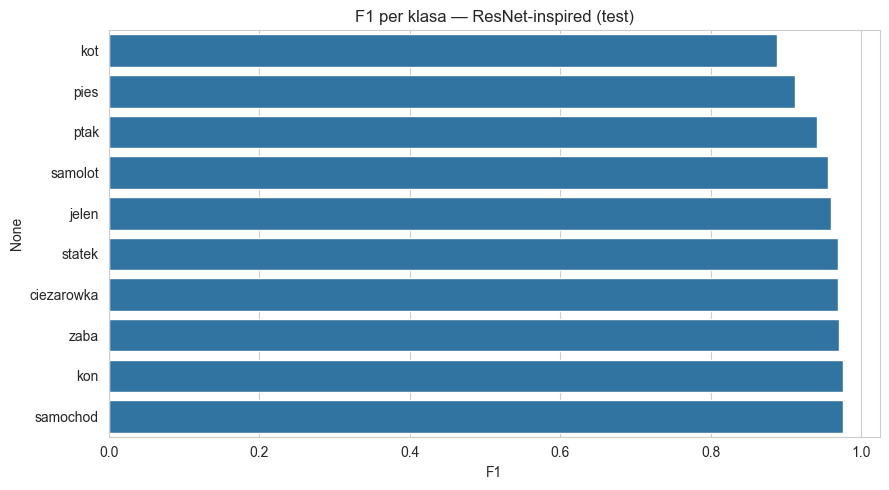

Najlepszy model: ResNet-inspired
Najtrudniejsze klasy: ['kot', 'pies', 'ptak']


In [20]:
# Najlepszy model wg test accuracy -> F1 per klasa.
candidates = [("Baseline (tuned)", baseline_best_test),
              ("VGG-like", res_vgg["test_metrics"]),
              ("ResNet-inspired", res_resnet["test_metrics"])]
best_label, best_metrics = max(candidates, key=lambda kv: kv[1]["accuracy"])

s = pd.Series(best_metrics["f1_per_class"]).sort_values()
plt.figure(figsize=(9, 5))
sns.barplot(x=s.values, y=s.index, orient="h")
plt.title(f"F1 per klasa — {best_label} (test)")
plt.xlabel("F1"); plt.tight_layout(); plt.show()
print("Najlepszy model:", best_label)
print("Najtrudniejsze klasy:", list(s.index[:3]))

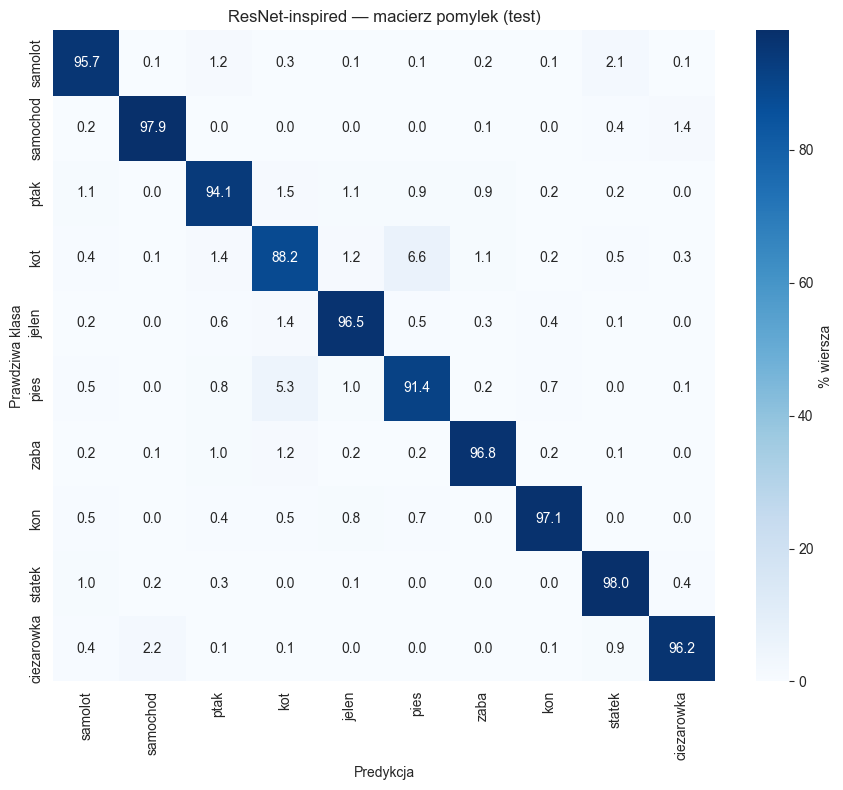

In [21]:
# Macierz pomylek najlepszego modelu.
cp.plot_confusion_matrix(best_metrics["y_true"], best_metrics["y_pred"],
                         title=f"{best_label} — macierz pomylek (test)")
plt.show()

### Podsumowanie narracyjne

Pełna ścieżka jakości (test accuracy):
**surowy baseline 78,1% → nastrojony baseline ~87% (val) → VGG-like 93,8% → ResNet-like 95,2%.**

- **Baseline (78,1%)** — prosta sieć Conv-BN-ReLU okazała się mocnym punktem startu już bez optymalizacji.
- **Adam vs SGD:** na surowo lepszy był Adam, ale po dodaniu cosine SGD przejął prowadzenie. Kluczem
  okazał się **harmonogram LR, nie sam optymalizator** — SGD + cosine dało 80,2%.
- **Strojenie (Etap 3):** największy pojedynczy zysk to **augmentacja danych** (+~6–7 pp); dropout, LR
  i batch_size miały znaczenie drugorzędne.
- **Głębokość (VGG-like):** mocno pomogła (+~6–7 pp), lecz czysta głębokość ma limit (zanikający gradient).
- **Skip connections (ResNet-like):** dalsza poprawa o +1,4 pp, ale kosztem ~2,8× parametrów — zysk malejący.
- **Najtrudniejsze klasy:** konsekwentnie **kot** i **pies** — zwierzęta o podobnej teksturze i sylwetce,
  mylone głównie między sobą oraz z pozostałymi zwierzętami (ptak, jeleń). Najłatwiejsze są pojazdy
  (samochód, ciężarówka, statek) i koń. Wzorzec utrzymuje się we wszystkich architekturach: **kot** jest
  najtrudniejszą klasą na każdym etapie, a jego `f1` rośnie 0,76 → 0,86 → 0,89 (baseline → VGG → ResNet).